In [ ]:
# pip install lasio pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path
import lasio
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

Current working directory:
/Users/akashray/Lithology_Predictor/notebooks


In [12]:
PROJECT_DIR = Path.home() / "Lithology_Predictor"

print("Project exists:", PROJECT_DIR.exists())
print("Project path:", PROJECT_DIR)

Project exists: True
Project path: /Users/akashray/Lithology_Predictor


In [13]:
DATA_DIR = PROJECT_DIR / "data" / "raw" / "FORCE_2020"

print("Data directory:")
print(DATA_DIR)

print("Exists:", DATA_DIR.exists())

Data directory:
/Users/akashray/Lithology_Predictor/data/raw/FORCE_2020
Exists: True


In [14]:
las_files = sorted(DATA_DIR.rglob("*.las"))

print("Number of LAS files:", len(las_files))

Number of LAS files: 118


In [7]:
DATA_DIR = Path("data/raw/FORCE_2020")

las_files = sorted(DATA_DIR.rglob("*.las"))

print("Number of LAS files:", len(las_files))
print("First 5 files:")

for f in las_files[:5]:
    print(f)

Number of LAS files: 0
First 5 files:


In [15]:
las_path = las_files[0]

print("Loading:")
print(las_path)

las = lasio.read(las_path)

print("\nLoaded successfully!")
print("Well:", las_path.name)

Loading:
/Users/akashray/Lithology_Predictor/data/raw/FORCE_2020/15_9-13.las

Loaded successfully!
Well: 15_9-13.las


In [19]:
las.curves

[CurveItem(mnemonic="DEPT", unit="m", value="", descr="DEPTH", original_mnemonic="DEPT", data.shape=(19586,)),
 CurveItem(mnemonic="FORCE_2020_LITHOFACIES_CONFIDENCE", unit="_", value="", descr="FORCE_2020_LITHOFACIES_CONFIDENCE", original_mnemonic="FORCE_2020_LITHOFACIES_CONFIDENCE", data.shape=(19586,)),
 CurveItem(mnemonic="FORCE_2020_LITHOFACIES_LITHOLOGY", unit="_", value="", descr="FORCE_2020_LITHOFACIES_LITHOLOGY", original_mnemonic="FORCE_2020_LITHOFACIES_LITHOLOGY", data.shape=(19586,)),
 CurveItem(mnemonic="CALI", unit="in", value="", descr="CALI", original_mnemonic="CALI", data.shape=(19586,)),
 CurveItem(mnemonic="BS", unit="in", value="", descr="BS", original_mnemonic="BS", data.shape=(19586,)),
 CurveItem(mnemonic="ROPA", unit="_", value="", descr="ROPA", original_mnemonic="ROPA", data.shape=(19586,)),
 CurveItem(mnemonic="ROP", unit="m/h", value="", descr="ROP", original_mnemonic="ROP", data.shape=(19586,)),
 CurveItem(mnemonic="RDEP", unit="ohm.m", value="", descr="RDEP

In [21]:
# i want to make a data file in whici it contain wells  x y z and the well name and the lithology of the well and the depth of the well
# for this i will use the las files and extract the data from it and then save it in a csv file

df_one = las.df()

print(df_one[["X_LOC", "Y_LOC", "Z_LOC"]].head(20))
df_one[["X_LOC", "Y_LOC", "Z_LOC"]].describe()

                 X_LOC      Y_LOC       Z_LOC
DEPT                                         
198.0164           NaN        NaN         NaN
198.1684  444904.00000  6421723.0 -154.168030
198.3204  444904.00000  6421723.0 -154.320038
198.4724  444904.00000  6421723.0 -154.472031
198.6244  444904.00000  6421723.0 -154.624039
198.7764  444904.00000  6421723.0 -154.776016
198.9284  444904.00000  6421723.0 -154.928024
199.0804  444904.00000  6421723.0 -155.080017
199.2324  444904.00000  6421723.0 -155.232025
199.3844  444904.00000  6421723.0 -155.384018
199.5364  444904.03125  6421723.0 -155.536011
199.6884  444904.03125  6421723.0 -155.688004
199.8404  444904.03125  6421723.0 -155.839996
199.9924  444904.03125  6421723.0 -155.992004
200.1444  444904.03125  6421723.0 -156.143997
200.2964  444904.03125  6421723.0 -156.296005
200.4484  444904.03125  6421723.0 -156.447983
200.6004  444904.03125  6421723.0 -156.599991
200.7524  444904.03125  6421723.0 -156.751984
200.9044  444904.03125  6421723.0 

,X_LOC,Y_LOC,Z_LOC
count,19544.000000,1.954400e+04,19544.000000
mean,444911.051247,6.421669e+06,-1632.896090
std,6.532153,6.524848e+01,850.737529
min,444904.000000,6.421578e+06,-3107.844727
25%,444905.812500,6.421580e+06,-2365.222046
50%,444906.656250,6.421722e+06,-1639.333923
75%,444920.281250,6.421724e+06,-896.787689
max,444920.468750,6.421727e+06,-154.168030


In [22]:
print("X unique values:", df_one["X_LOC"].nunique())
print("Y unique values:", df_one["Y_LOC"].nunique())
print("Z unique values:", df_one["Z_LOC"].nunique())

X unique values: 528
Y unique values: 299
Z unique values: 19544


In [23]:
records = []

for las_path in las_files:

    try:
        las_i = lasio.read(las_path)
        data = las_i.df()

        # Make sure required coordinate curves exist
        required = ["X_LOC", "Y_LOC", "Z_LOC"]

        if not all(col in data.columns for col in required):
            print(f"Missing coordinate curve: {las_path.name}")
            continue

        # Get first valid coordinate
        x = data["X_LOC"].dropna().iloc[0]
        y = data["Y_LOC"].dropna().iloc[0]
        z = data["Z_LOC"].dropna().iloc[0]

        # Get well name from header
        well_name = las_i.well["WELL"].value

        records.append({
            "well": well_name,
            "file": las_path.name,
            "X": x,
            "Y": y,
            "Z": z
        })

    except Exception as e:
        print(f"Error: {las_path.name}")
        print(e)

In [25]:
well_locations = pd.DataFrame(records)

print("Number of wells:", len(well_locations))

well_locations.head()

Number of wells: 118


,well,file,X,Y,Z
0,15/9-13 Sleipner East Appr,15_9-13.las,437642.15625,6470975.5,-73.719467
1,15/9-14,15_9-14.las,423245.53125,6461862.0,-73.804001
2,15/9-15 Gungne,15_9-15.las,436817.40625,6462991.5,-146.832001
3,15/9-17,15_9-17.las,438591.62500,6478949.5,-105.994339
4,15/9-23 Skardkollen,15_9-23.las,433900.50000,6460000.5,-148.380005


In [26]:
well_locations[["X", "Y", "Z"]].isna().sum()

X    0
Y    0
Z    0
dtype: int64

In [27]:
well_locations.to_csv(
    "FORCE_2020_well_locations.csv",
    index=False
)

print("Saved: FORCE_2020_well_locations.csv")

Saved: FORCE_2020_well_locations.csv


In [7]:
df = pd.read_csv("FORCE_2020_well_locations.csv")

In [30]:
df.head()

,well,file,X,Y,Z
0,15/9-13 Sleipner East Appr,15_9-13.las,437642.15625,6470975.5,-73.719467
1,15/9-14,15_9-14.las,423245.53125,6461862.0,-73.804001
2,15/9-15 Gungne,15_9-15.las,436817.40625,6462991.5,-146.832001
3,15/9-17,15_9-17.las,438591.62500,6478949.5,-105.994339
4,15/9-23 Skardkollen,15_9-23.las,433900.50000,6460000.5,-148.380005


In [8]:
df["X"] = pd.to_numeric(df["X"], errors="coerce")
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")
df["Z"] = pd.to_numeric(df["Z"], errors="coerce")

plot_df = df.dropna(subset=["X", "Y"]).copy()

print("Total wells:", len(df))
print("Wells with X-Y coordinates:", len(plot_df))

Total wells: 118
Wells with X-Y coordinates: 118


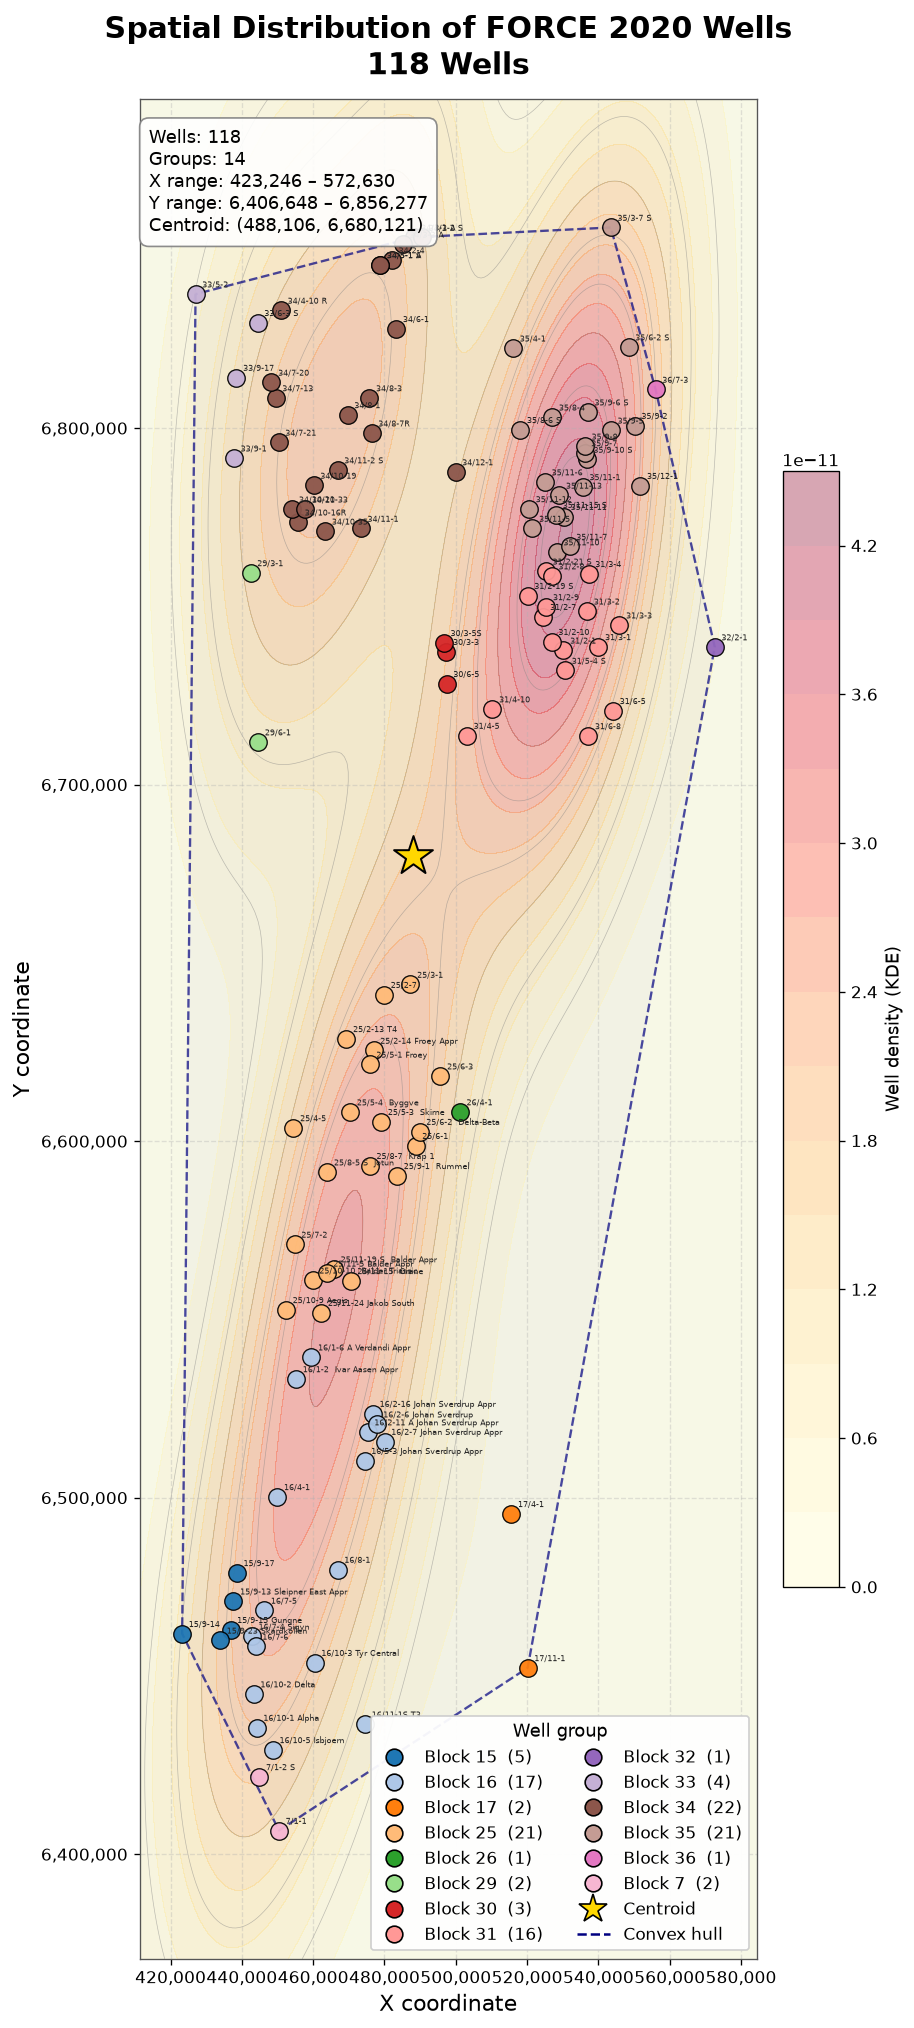

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde

# ---------------------------------------------------------------
# Assumes plot_df exists with columns: "well", "X", "Y"
# ---------------------------------------------------------------
df = plot_df.dropna(subset=["X", "Y"]).copy()

# Group wells by North Sea quadrant/block, e.g. "15/9-13" -> "15"
# (falls back to a single group if names don't follow that pattern)
df["group"] = df["well"].astype(str).str.extract(r"^(\d+)/")[0].fillna("Other")
groups = sorted(df["group"].unique(), key=lambda g: (g == "Other", g))
cmap = plt.get_cmap("tab20" if len(groups) > 10 else "tab10")
colors = {g: cmap(i % cmap.N) for i, g in enumerate(groups)}

fig, ax = plt.subplots(figsize=(22, 17), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("#f4f7fb")

x, y = df["X"].to_numpy(), df["Y"].to_numpy()

# 1) Well-density heat surface in the background
if len(df) > 5:
    pad_x, pad_y = 0.08 * np.ptp(x), 0.08 * np.ptp(y)
    gx, gy = np.mgrid[x.min() - pad_x:x.max() + pad_x:200j,
                      y.min() - pad_y:y.max() + pad_y:200j]
    kde = gaussian_kde(np.vstack([x, y]))
    z = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    cf = ax.contourf(gx, gy, z, levels=15, cmap="YlOrRd", alpha=0.35, zorder=1)
    ax.contour(gx, gy, z, levels=8, colors="gray", linewidths=0.4, alpha=0.5, zorder=1)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.6, pad=0.01)
    cbar.set_label("Well density (KDE)", fontsize=11)

# 2) Convex hull outline of the field
if len(df) >= 3:
    hull = ConvexHull(np.c_[x, y])
    hv = np.append(hull.vertices, hull.vertices[0])
    ax.plot(x[hv], y[hv], color="navy", lw=1.4, ls="--", alpha=0.7, zorder=2)
    ax.fill(x[hv], y[hv], color="navy", alpha=0.03, zorder=0)

# 3) Wells coloured by group
for g in groups:
    sub = df[df["group"] == g]
    ax.scatter(sub["X"], sub["Y"], s=110, color=colors[g],
               edgecolor="black", linewidth=0.8, alpha=0.95, zorder=4)

# 4) Small well labels (auto-avoid overlaps if adjustText is installed)
texts = [ax.text(r.X, r.Y, str(r.well), fontsize=5, color="#222222", zorder=5)
         for r in df.itertuples()]
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.3))
except ImportError:
    for t in texts:
        t.set_position((t.get_position()[0], t.get_position()[1]))
        t.set_transform(ax.transData + plt.matplotlib.transforms.ScaledTranslation(
            4 / 72, 4 / 72, fig.dpi_scale_trans))

# 5) Centroid marker
cx, cy = x.mean(), y.mean()
ax.scatter(cx, cy, marker="*", s=600, color="gold", edgecolor="black",
           linewidth=1.2, zorder=6)

# 6) Stats box
stats = (f"Wells: {len(df)}\n"
         f"Groups: {len(groups)}\n"
         f"X range: {x.min():,.0f} – {x.max():,.0f}\n"
         f"Y range: {y.min():,.0f} – {y.max():,.0f}\n"
         f"Centroid: ({cx:,.0f}, {cy:,.0f})")
ax.text(0.015, 0.985, stats, transform=ax.transAxes, va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.9),
        zorder=7)

# 7) Legend
handles = [Line2D([0], [0], marker="o", ls="", markerfacecolor=colors[g],
                  markeredgecolor="black", markersize=10,
                  label=f"Block {g}  ({(df['group'] == g).sum()})") for g in groups]
handles += [Line2D([0], [0], marker="*", ls="", markerfacecolor="gold",
                   markeredgecolor="black", markersize=18, label="Centroid"),
            Line2D([0], [0], color="navy", ls="--", label="Convex hull")]
ax.legend(handles=handles, title="Well group", loc="lower right",
          fontsize=10, title_fontsize=11, framealpha=0.95, ncol=2)

# 8) Axes, grid, title
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_xlabel("X coordinate", fontsize=13)
ax.set_ylabel("Y coordinate", fontsize=13)
ax.set_title(f"Spatial Distribution of FORCE 2020 Wells\n{len(df)} Wells",
             fontsize=18, fontweight="bold", pad=15)
ax.grid(True, ls="--", alpha=0.35, zorder=0)
ax.set_aspect("equal", adjustable="box")
for s in ax.spines.values():
    s.set_color("#555555")

plt.tight_layout()
plt.savefig("force2020_well_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
!pip install plotly

In [18]:
import numpy as np
import plotly.graph_objects as go

# ---------------------------------------------------------------
# Assumes plot3d_df exists with columns: "well", "X", "Y", "Z"
# ---------------------------------------------------------------
df = plot3d_df.dropna(subset=["X", "Y", "Z"]).copy().reset_index(drop=True)
df["well"] = df["well"].astype(str)

# Group by North Sea block, e.g. "15/9-13" -> "15" (used for hover/filtering)
df["block"] = df["well"].str.extract(r"^(\d+)/")[0].fillna("Other")

n = len(df)
x, y, z = df["X"].to_numpy(), df["Y"].to_numpy(), df["Z"].to_numpy()

# Stem length scales with the data (5% of Z range) instead of a fixed 100
z_range = np.ptp(z) if np.ptp(z) > 0 else 1.0
stem_len = 0.05 * z_range
z_floor = z.min() - 2.5 * stem_len          # plane for shadow projection

# Vertical exaggeration so the Z axis doesn't get flattened by aspectmode="data"
xy_span = max(np.ptp(x), np.ptp(y), 1.0)
z_aspect = min(max(0.35, z_range / xy_span), 0.8)

fig = go.Figure()

# ---------------------------------------------------------------
# 1) ALL vertical stems in ONE trace (None separates segments).
#    One trace instead of one per well -> stays fast with 1000s of wells.
# ---------------------------------------------------------------
sx = np.empty(n * 3); sy = np.empty(n * 3); sz = np.empty(n * 3)
sx[0::3], sx[1::3], sx[2::3] = x, x, np.nan
sy[0::3], sy[1::3], sy[2::3] = y, y, np.nan
sz[0::3], sz[1::3], sz[2::3] = z, z - stem_len, np.nan

fig.add_trace(go.Scatter3d(
    x=sx, y=sy, z=sz, mode="lines",
    line=dict(width=4, color="rgba(180,190,210,0.55)"),
    hoverinfo="skip", showlegend=False, name="Stems"))

# ---------------------------------------------------------------
# 2) Ground "shadow" projection of wells onto a floor plane
# ---------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=np.full(n, z_floor), mode="markers",
    marker=dict(size=3, color="rgba(255,255,255,0.35)"),
    hoverinfo="skip", name="Map projection", visible=True))

# Faint drop-lines from wellhead to the floor
dx = np.empty(n * 3); dy = np.empty(n * 3); dz = np.empty(n * 3)
dx[0::3], dx[1::3], dx[2::3] = x, x, np.nan
dy[0::3], dy[1::3], dy[2::3] = y, y, np.nan
dz[0::3], dz[1::3], dz[2::3] = z - stem_len, z_floor, np.nan
fig.add_trace(go.Scatter3d(
    x=dx, y=dy, z=dz, mode="lines",
    line=dict(width=1, color="rgba(255,255,255,0.12)"),
    hoverinfo="skip", showlegend=False, name="Drop lines"))

# ---------------------------------------------------------------
# 3) Wellheads coloured by Z (continuous colourscale + colourbar)
# ---------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z, mode="markers",
    marker=dict(
        size=6, symbol="diamond",
        color=z, colorscale="Turbo",
        colorbar=dict(title="Z", thickness=14, len=0.6, x=0.98),
        line=dict(width=0.6, color="black"),
        opacity=0.95),
    text=df["well"], customdata=df["block"],
    hovertemplate=("<b>%{text}</b><br>Block: %{customdata}<br>"
                   "X: %{x:,.2f}<br>Y: %{y:,.2f}<br>Z: %{z:,.2f}"
                   "<extra></extra>"),
    name="Well locations"))

# ---------------------------------------------------------------
# 4) Small text labels (toggle with the buttons below)
# ---------------------------------------------------------------
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z + 0.5 * stem_len, mode="text",
    text=df["well"], textposition="top center",
    textfont=dict(size=7, color="white"),
    hoverinfo="skip", name="Labels", visible=False))

label_idx = len(fig.data) - 1
shadow_idx = 1

# ---------------------------------------------------------------
# Layout: dark theme, camera, toggle buttons
# ---------------------------------------------------------------
axis_style = dict(
    backgroundcolor="rgb(18,22,32)", gridcolor="rgba(255,255,255,0.12)",
    zerolinecolor="rgba(255,255,255,0.2)", showspikes=False,
    color="white", tickfont=dict(size=10))

fig.update_layout(
    title=dict(text=f"FORCE 2020 — Interactive 3D Well Locations ({n} wells)",
               font=dict(size=20, color="white"), x=0.5),
    template="plotly_dark",
    paper_bgcolor="rgb(12,15,22)",
    scene=dict(
        xaxis=dict(title="X coordinate", **axis_style),
        yaxis=dict(title="Y coordinate", **axis_style),
        zaxis=dict(title="Z coordinate", **axis_style),
        aspectmode="manual",
        aspectratio=dict(x=1, y=max(np.ptp(y) / xy_span, 0.3), z=z_aspect),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9))),
    legend=dict(bgcolor="rgba(30,35,50,0.7)", x=0.01, y=0.98),
    margin=dict(l=0, r=0, t=60, b=0),
    autosize=True,          # fills the browser window / notebook cell
    height=850,
    updatemenus=[
        dict(type="buttons", direction="right", x=0.5, y=0.02,
             xanchor="center", bgcolor="rgb(40,46,64)",
             buttons=[
                 dict(label="Labels ON", method="restyle",
                      args=[{"visible": True}, [label_idx]]),
                 dict(label="Labels OFF", method="restyle",
                      args=[{"visible": False}, [label_idx]]),
                 dict(label="Top view", method="relayout",
                      args=[{"scene.camera.eye": dict(x=0, y=0, z=2.6)}]),
                 dict(label="Side view", method="relayout",
                      args=[{"scene.camera.eye": dict(x=2.4, y=0, z=0.2)}]),
                 dict(label="3D view", method="relayout",
                      args=[{"scene.camera.eye": dict(x=1.6, y=-1.6, z=0.9)}]),
             ])])

fig.write_html("force2020_wells_3d.html", include_plotlyjs="cdn",
               full_html=True, config={"responsive": True, "displaylogo": False})
fig.show(renderer="browser")